# Task 3: Unsupervised Learning
**Objective:** Apply clustering algorithms to identify groupings in the data and visualize them using PCA.
**Inputs:** `../data/cleaned.csv`
**Outputs:** `../data/clustered.csv`

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.decomposition import PCA
from scipy.sparse import hstack

df = pd.read_csv('../data/cleaned.csv')

df['Review_Word_Count'] = df['Translated_Review'].apply(lambda x: len(str(x).split()))
df['Review_Char_Count'] = df['Translated_Review'].apply(lambda x: len(str(x)))

### Feature Extraction
**Action:** Recreate TF-IDF and scale numerical features to prepare the matrix for clustering.

In [2]:
X_text = df['Translated_Review'].astype(str)
tfidf = TfidfVectorizer(max_features=500)
X_tfidf = tfidf.fit_transform(X_text)

scaler = StandardScaler()
X_num = scaler.fit_transform(df[['Review_Word_Count', 'Review_Char_Count']])

X = hstack((X_tfidf, X_num)).toarray()

### Clustering Algorithms
**Action:** Apply KMeans and MiniBatchKMeans to group the reviews into 3 clusters.

In [3]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster_kmeans'] = kmeans.fit_predict(X)

mb_kmeans = MiniBatchKMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster_mbkmeans'] = mb_kmeans.fit_predict(X)

df['cluster_label'] = df['cluster_kmeans']

### Dimensionality Reduction and Visualization
**Action:** Reduce features to 2 dimensions using PCA and plot the resulting clusters.

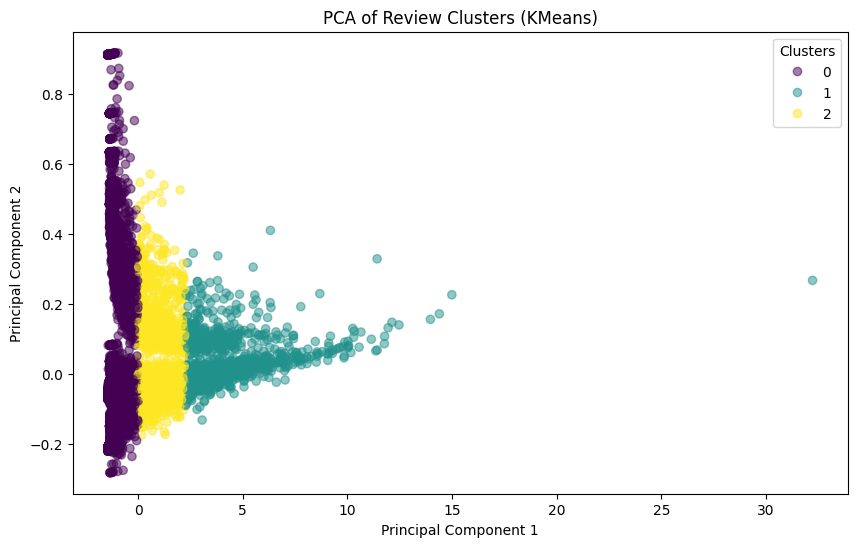

In [4]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['PCA1'], df['PCA2'], c=df['cluster_label'], cmap='viridis', alpha=0.5)
plt.title('PCA of Review Clusters (KMeans)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.savefig('../reports/cluster_pca.png', bbox_inches='tight')
plt.show()

### Export Clustered Data
**Action:** Save the dataset with the new cluster_label column for Task 4.

In [5]:
df.drop(columns=['PCA1', 'PCA2', 'cluster_kmeans', 'cluster_mbkmeans'], inplace=True)
df.to_csv('../data/clustered.csv', index=False)